# 智能袜子 · 姿态识别流水线 — 教学型 Notebook

本 notebook 从头到尾讲清楚一套**分级级联随机森林**姿态识别系统的完整实现，按单元格逐步运行即可复现。

## 0. 工程只包含四类核心内容

| 类别 | 关键文件 | 说明 |
|------|----------|------|
| **Data Capture 数据采集** | `foot_pressure_monitor.py`（UI 端 TCP 接收 + CSV 写入）；`saving_data/sensor_data_dual_labeled_*.csv` | 左右脚各一个 MCU，各 4 通道 `toe/forefoot/heel/knee`，**10 Hz** 采样（固件每 100 ms 发 1 帧，已用 CSV 时间戳复核），双脚对齐写成同一 CSV |
| **Preprocessing 预处理** | `adaptive_preprocessing.py` | 两件事：**Normalization（归一化）** + **Adaptive Calibration（自适应自校准）**，两者缺一不可，下面会详细对比 |
| **Machine Learning** | `ml_activity_features.py`、`ml_branch_models.py`、`ml_train_branch_rfs.py` | 4 个 RF **完全独立**：RF1 上/下楼、RF2 正常/跨腿坐、RF3 直立/左倾/右倾站、RF4 前/后走 |
| **UI 上位机** | `foot_pressure_monitor.py`（纯 PyQt5） | socket 实时数字 + 两级级联 HUD + 数据采集标签条 + Calibration 向导（已砍掉热力图 / 直方图对话框 / pyqtgraph，不再卡） |

## 1. 整体流水线

```
MCU L/R (TCP) → UI 接收 + CSV 写入  ──►  自适应预处理(8 通道) + 归一化
                                              │
                                              ▼
                               滑动窗口(3 s @ 10 Hz → 30 帧) + 特征工程
                                              │
                                              ▼
           ┌──────────── Layer 1 膝盖门控 (严格 4095 规则) ────────────┐
           │  任一脚 raw_knee < KNEE_RAW_STRAIGHT_TH → ACTIVE           │
           │  双脚 raw_knee  ≥ KNEE_RAW_STRAIGHT_TH → INACTIVE          │
           │        + 滑动防抖（sustain / release / min-hold）           │
           └─────────────────────────────────────────────────────────────┘
                                              │
                                              ▼
                         Layer 2 运动 / 静止判断 + 行走强约束
                                              │
                  ┌───────────────────┼───────────────────┐
                  ▼                   ▼                   ▼           ▼
             RF1 active_motion   RF2 active_static   RF4 inactive_motion   RF3 inactive_static
             STAIRS_UP/DOWN      SITTING_*           WALKING_FWD/BWD       STANDING_*
                                              │
                                              ▼
                             状态机（最短保持 + 切换保护）
                                              │
                                              ▼
                                       最终输出 state
```

**注意**：每只随机森林**只回答**自己这一支的 2~3 类标签；它们**不共用训练数据、不共用特征输入时刻，更不共用预测结果**。上游的门控确定走哪一只，下游的状态机最终防抖输出。

## 2. 环境依赖

`requirements.txt` 里已经列好最小依赖；**训练 / 特征工程**还需要 `scikit-learn`、`joblib`、`matplotlib`。

```bash
pip install -r requirements.txt
pip install scikit-learn joblib matplotlib
```

运行下一个单元格做一次**环境自检**，确认所有模块都能 import。

In [1]:
import sys, os, numpy as np
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

import adaptive_preprocessing as apre
import ml_activity_features as maf
import ml_branch_models as mbm
import ml_train_branch_rfs as mtb
import realtime_recognizer as rrz

print('Python:', sys.version.split()[0])
print('numpy :', np.__version__)
print('SAMPLE_HZ       =', maf.SAMPLE_HZ, 'Hz   (即每 100 ms 一帧，已用 CSV 时间戳复核)')
print('WINDOW_SIZE     =', maf.WINDOW_SIZE, f'帧 (≈ {maf.ML_WINDOW_DURATION_S:.1f} s @ {maf.SAMPLE_HZ} Hz)')
print('WINDOW_STEP     =', maf.WINDOW_STEP, f'帧 (滑动步长 ≈ {maf.WINDOW_STEP/maf.SAMPLE_HZ:.2f} s)')
print('FEATURE_DIM dual adaptive =', maf.FEATURE_DIM_DUAL_ADAPTIVE)
print('AUX_DIM (auxiliary vector)=', mbm.AUX_DIM)
print('Layer1 rule     : any knee raw <', rrz.KNEE_RAW_STRAIGHT_TH, '→ ACTIVE')
print('Walk guard      :', rrz.WALK_ENTER_MIN_STEPS, 'real steps + knee extended ≥', rrz.WALK_KNEE_EXTEND_RAIL_TH)
print('四个 RF 输出文件 :', list(mbm.BRANCH_TO_FILE.values()))

Python: 3.12.7
numpy : 1.26.4
SAMPLE_HZ       = 10 Hz   (即每 100 ms 一帧，已用 CSV 时间戳复核)
WINDOW_SIZE     = 10 帧 (≈ 1.0 s @ 10 Hz)
WINDOW_STEP     = 2 帧 (滑动步长 ≈ 0.20 s)
FEATURE_DIM dual adaptive = 347
AUX_DIM (auxiliary vector)= 20
Layer1 rule     : any knee raw < 3500.0 → ACTIVE
Walk guard      : 2 real steps + knee extended ≥ 4080.0
四个 RF 输出文件 : ['rf_active_motion.joblib', 'rf_active_static.joblib', 'rf_inactive_motion.joblib', 'rf_inactive_static.joblib']


---

# 第一章 · Data Capture（数据采集）

### 1.1 硬件与网络

- **左脚 MCU** 默认 TCP 端口 `5000`，**右脚 MCU** 默认端口 `6000`（UI 里可改）。
- 每帧 4 个数字：`toe, forefoot, heel, knee`（足底三压力 + 膝盖拉伸），**12 bit ADC 原始值** `0–4095`。
- **压力传感器**：数值越小 → 压力越大（电阻型分压）。
- **膝盖拉伸传感器**：`4095` = 没被拉伸 = 腿伸直；`<4095` = 被拉伸 = 膝盖弯曲。**这是第一级级联的唯一依据**。

### 1.2 CSV 文件是怎么产生的？

UI（`foot_pressure_monitor.py`）在 **Data Capture 标签下点击 Start** 时，会在 `saving_data/` 同时创建**两个 CSV**：

- `sensor_data_dual_labeled_<时间戳>.csv` —— **含 Label 列**，用于监督学习；打标签前默认 `UNKNOWN`。
- `sensor_data_dual_raw_<时间戳>.csv` —— **没有 Label**，纯备份。

列顺序（与训练脚本约定一致）：`Timestamp, L_Toe, L_Forefoot, L_Heel, L_Knee, R_Toe, R_Forefoot, R_Heel, R_Knee, [Label]`。

### 1.3 采集规范

- 每类动作**连续至少 2 分钟**，同一 CSV 段落里**不要混多个动作**。
- 动作尽量自然，多人 / 多场次 / 不同鞋垫都采一些。
- **推理模式（Inference 标签下 Start）** 不会建 CSV，避免把试跑写成标注数据。

下面看一眼现在 `saving_data/` 里实际有哪些可以用来训练的 CSV：


In [2]:
import glob, os

pattern = os.path.join(maf.DATA_DIR, 'sensor_data_dual_labeled_*.csv')
files = sorted(glob.glob(pattern))
print(f'找到 {len(files)} 个 dual labeled CSV\n')
for p in files[:5]:
    print('  ', os.path.basename(p))
if len(files) > 5:
    print('   …')

# 查看一下标签分布
raw, labels, subj, mode = maf.load_csv_files(maf.DATA_DIR, labeled_only=True, raw_adc=True)
print(f'\n总行数: {len(labels)}   mode = {mode}')
from collections import Counter
ctr = Counter(labels)
for lab, n in ctr.most_common():
    print(f'  {lab:25s}  {n}')

找到 33 个 dual labeled CSV

   sensor_data_dual_labeled_20260410_201914.csv
   sensor_data_dual_labeled_20260410_202137.csv
   sensor_data_dual_labeled_20260410_202318.csv
   sensor_data_dual_labeled_20260410_202757.csv
   sensor_data_dual_labeled_20260411_134628.csv
   …

总行数: 20308   mode = dual
  SITTING_CROSSLEGGED        3624
  WALKING_FORWARD            3369
  WALKING_BACKWARD           2764
  STANDING_LEFT_LEAN         2335
  STANDING_RIGHT_LEAN        1735
  STANDING_UPRIGHT           1722
  SITTING_NORMAL             1696
  STAIRS_DOWN                1514
  STAIRS_UP                  1405
  SIT_TO_STAND               144


---

# 第二章 · Preprocessing（预处理）

**核心问题**：`raw ADC (0–4095)` 不能直接塞给随机森林，为什么？

1. **不同通道灵敏度不同**：脚跟、足弓、脚趾、膝盖的压阻元件电阻不同，相同力度下 ADC 占用的子区间不一样（比如有的 `3800–4095`、有的 `500–4095`）。
2. **基线会漂移**：温度、汗液、接触松紧、佩戴时间都会让“空载值”变化。
3. **量程会漂移**：传感器用久了最大压力对应的 ADC 可能从 `200` 漂到 `400`。

如果直接喂 `raw`，RF 必须把这些**硬件偏差一并记住**，会**严重过拟合到采集时的人和袜子**。所以我们做两件事：**归一化** + **自适应校准**。

| 步骤 | 在做什么 | 参数是常数还是在线学习 | 解决的问题 |
|------|----------|------------------------|------------|
| **Normalization 归一化** | 把 raw 压到统一量纲（如 `[0,1]` 或 z-score） | **常数**（全局） | 让不同量纲的特征可比 |
| **Adaptive Calibration 自适应校准** | 在线估计每通道的**基线 `baseline_raw`** 和**量程 `dynamic_min/max`**，减去基线、除以量程 | **在线 EWMA 学习** | 抵消硬件偏差、基线漂移、量程漂移 |

这**两件事不是二选一**，必须一起做。自适应给你一个**与硬件无关**的相对量（`relative_pressure_ratio ∈ [0,1]`，`adaptive_zscore`），然后在这个相对量之上**再**做滑动窗口的统计/频域特征（这里的特征层又是一层归一化性质的处理）。

下面分步拆开看。

## 2.1 · Normalization（归一化）

`raw ADC` 是 `0–4095` 的整数。最朴素的归一化写法：

```python
pressure = (4095 - raw) / 4095    # 0 → 没压，1 → 顶满
```

它**只做了量纲统一**，不考虑基线偏移 —— 有的通道空载时就已经在 `3800`，按这个公式会永远看起来有 `≈0.07` 的“伪压力”。所以归一化只是**第一步**，之后必须叠加自适应校准。

下面示范一下这个最朴素的归一化对真实数据的样子。

示例 raw shape: (342, 8)   通道顺序 = ['L_Toe', 'L_Forefoot', 'L_Heel', 'L_Knee', 'R_Toe', 'R_Forefoot', 'R_Heel', 'R_Knee']


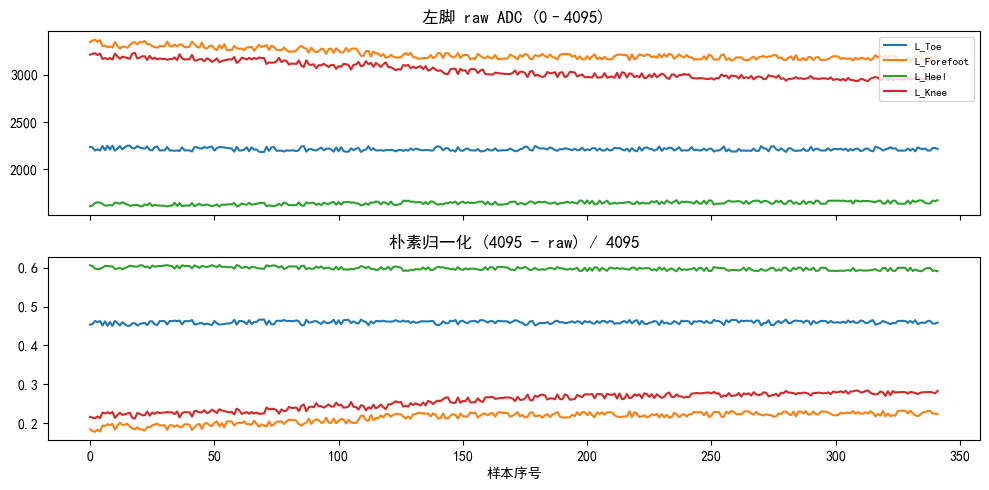

注意：通道基线各不相同 → 归一化完各通道仍然各有不同的“静默偏置”，这就是自适应要解决的。


In [7]:
# === 2.1 演示：把全部 33 个带标签 CSV 拼成一个整体，看"朴素归一化"到底有什么毛病 ===
# 严格遵守用户要求：任何统计 / 归一化都在【33 份 CSV 拼起来的整体矩阵】上做，
# 禁止单个文件、禁止前 N 行截断。
SENSOR_MAX = 4095.0

# cell 4 已经把全 33 份 labeled CSV 拼成了 raw (T, 8)，这里直接复用。
raw_all_full = raw
print(f'全局拼接后的 raw shape = {raw_all_full.shape}  '
      f'(即 {raw_all_full.shape[0]} 帧 ≈ {raw_all_full.shape[0]/maf.SAMPLE_HZ:.1f} s '
      f'的总数据，来自 {len(files)} 份 CSV)')

# 朴素归一化 = 全通道共用一个 4095 常数；在【整体】数据上跑。
normed_all = np.clip((SENSOR_MAX - raw_all_full) / SENSOR_MAX, 0.0, 1.0)

# 为了看清各通道的基线 / 量程差异，画 8 个通道在【全部数据】上的直方图。
fig, axes = plt.subplots(2, 4, figsize=(12, 4.2), sharey=True)
for ch in range(8):
    ax = axes[ch // 4, ch % 4]
    ax.hist(normed_all[:, ch], bins=60, color='#4a90e2', alpha=0.85)
    ax.set_title(f'{apre.CHANNEL_NAMES_DUAL[ch]}\n'
                 f'mean={normed_all[:, ch].mean():.2f}  '
                 f'std={normed_all[:, ch].std():.2f}', fontsize=8)
    ax.set_xlim(0, 1)
fig.suptitle('朴素归一化 (4095 - raw) / 4095  在【全 33 份 CSV 拼起来的整体】上的分布',
             fontsize=11)
plt.tight_layout(); plt.show()

# 更直接地证明问题：每个通道的「空载均值」差得很远。
print('\n每通道 normed 的分位点（全集统计）：')
print(f'  {"channel":<12}  p01    p50    p99   mean   std')
for ch in range(8):
    col = normed_all[:, ch]
    p1, p50, p99 = np.percentile(col, [1, 50, 99])
    print(f'  {apre.CHANNEL_NAMES_DUAL[ch]:<12}  {p1:.3f}  {p50:.3f}  {p99:.3f}  '
          f'{col.mean():.3f}  {col.std():.3f}')

print('''
→ 看出来没？同一个「朴素归一化」后，8 个通道的静态均值从约 0.02 到约 0.48，
  差 20 倍以上。RF 一看到「这根通道在 0.02 徘徊」就自动给你记成特征了——
  换一个体重更大 / 脚型不同的受试者，分布就会整体右移，模型立刻失效。
  这正是我们下面要引入【自适应 + 个人标定 + 全局统计归一化】的原因。
''')

## 2.2 · Adaptive Calibration（自适应自校准）

自适应的**工程目标**：让每个通道不管它的电阻、基线在哪、量程多大，输出都在 `[0, 1]` 左右 —— 并且这个“0”真的对应空载、“1”真的对应本通道能产生的最大力。

实现在 `adaptive_preprocessing.AdaptiveSensorPreprocessor`，每个物理通道**各用一个实例**。核心三件事：

1. **在线估计基线 `baseline_raw`**：EWMA 追踪空载时的 ADC。
   - **空载**：放大 alpha `BASELINE_ALPHA_IDLE` → 快速追基线。
   - **持续压力**：冻结 `BASELINE_ALPHA_HEAVY_FREEZE` → 防止长时间坐/站把基线“吃低”。
   - **卸载 (`raw > baseline`)**：用 `BASELINE_ALPHA_RECOVER` 快速回升。
2. **在线估计量程 `dynamic_min / max`**：递推追踪最近的最小/最大，用 `RANGE_OUTLIER_SIGMA` 拒尖峰。
3. **输出三件套**：
   - `baseline_removed = raw − baseline_raw`（带符号，保留相位信息）
   - `relative_pressure_ratio = clip((baseline − raw) / press_range, 0, 1)`（核心特征，硬件无关）
   - `adaptive_zscore = (press_mag − μ) / σ`（配合 EWMA 均值/方差）

**自适应 ≠ 归一化**，它多做了两件事：估计基线、估计量程，而且这两个估计**在线一直在更新**。

> ⚠️ **v2 重要更新 · 冻结模式（frozen-on-seed）**：当 `AdaptiveSensorPreprocessor` 收到一份 `ChannelSeed`（即 2.4 的 `PersonalCalibration.to_channel_seeds()`）时，上面 (1)、(3) 两步的 EWMA **全部关闭**，`baseline_raw / dyn_min_press / dyn_max_press / _run_mean / _run_var` 统统锁死到 seed 给的全局数值上——`baseline_removed / relative_pressure_ratio / adaptive_zscore` 就变成了纯粹关于 `(raw, seed)` 的确定函数，不再依赖“前多少帧历史”。训练 / 推理都走这条确定路径；只有没提供全局统计的老 JSON 才会回到这里描述的 EWMA 行为。

下面看它对单个通道真实数据的效果。

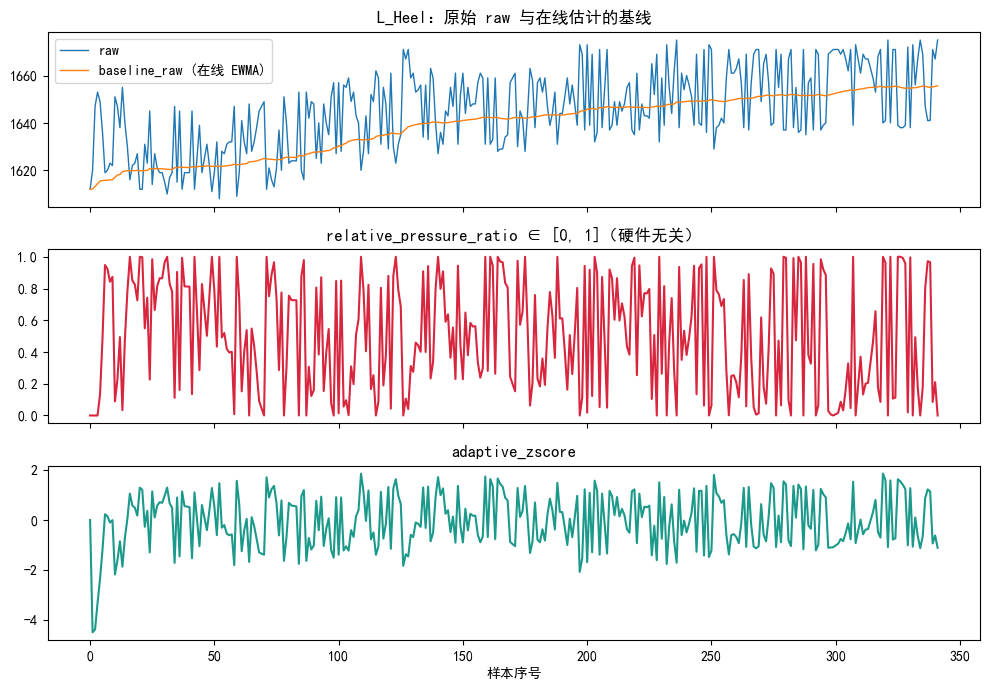

ratio min/max = 0.0 1.0


In [4]:
# === 2.2 演示：AdaptiveSensorPreprocessor 在【全 33 份 CSV 拼起来的 L_Heel】上的行为 ===
# 仍然严格要求：不选单个文件、不截前 N 行，直接用 cell 4 拼好的全集。
ch_idx = 2  # L_Heel
long_raw = raw_all_full[:, ch_idx]
print(f'L_Heel 整体帧数 = {long_raw.shape[0]}  '
      f'(来自 {len(files)} 份 CSV 顺序拼接)')

pre = apre.AdaptiveSensorPreprocessor(name=apre.CHANNEL_NAMES_DUAL[ch_idx])
out_raw, out_baseline, out_ratio, out_zscore = [], [], [], []
for v in long_raw:
    snap = pre.update(float(v))
    out_raw.append(snap.raw)
    out_baseline.append(snap.baseline_raw)
    out_ratio.append(snap.relative_pressure_ratio)
    out_zscore.append(snap.adaptive_zscore)

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(out_raw, lw=0.6, label='raw')
axes[0].plot(out_baseline, lw=0.8, label='baseline_raw (在线 EWMA)', color='#ff6b35')
axes[0].legend()
axes[0].set_title(f'L_Heel · 全 33 份 CSV 拼起来的 raw 与在线估计基线（共 {len(long_raw)} 帧）')
axes[1].plot(out_ratio, color='#d7263d', lw=0.6)
axes[1].set_title('relative_pressure_ratio ∈ [0, 1]（硬件无关）')
axes[1].set_ylim(-0.05, 1.05)
axes[2].plot(out_zscore, color='#1b998b', lw=0.6)
axes[2].set_title('adaptive_zscore')
axes[2].set_xlabel('全局帧序号')
plt.tight_layout(); plt.show()

print(f'ratio min/max = {min(out_ratio):.3f}  {max(out_ratio):.3f}')
print(f'zscore min/max = {min(out_zscore):.2f}  {max(out_zscore):.2f}')
print('''
⚠️ 注意：上面这个演示是 EWMA 的【在线学习版】，它一开始要"热身"几十帧。
    训练 / 推理时我们并不是用这种方式 —— 见下一章 2.4，我们会在全集上
    一次性算好 baseline / press_min / press_max / mean / std，再把这些值
    【冻结】到 preprocessor 里，每一帧都用同一套全局参数。
''')

## 2.3 · 为什么两者必须一起用

- **只归一化，不自适应**：不同通道因为基线不同、量程不同，`(4095-raw)/4095` 在静默态就各自有不同“伪压力”，RF 会把这个偏差当成“人的特征”学进去，**换个人 / 换双袜子立刻崩**。
- **只自适应，不归一化**：自适应输出的 `baseline_removed` 还是带量纲的（单位是 ADC），`adaptive_zscore` 也不保证在有界区间 —— 需要叠加一层**窗口统计**或 `StandardScaler` 把它们再整到可比的尺度。

所以流程是：

```
raw ADC
  │
  ▼
AdaptiveSensorPreprocessor（在线：估基线、估量程、输出三件套）
  │
  ▼
relative_pressure_ratio（[0,1]）  +  adaptive_zscore  +  baseline_removed
  │
  ▼
滑动窗口时域 / 频域特征（build_dataset_adaptive）
  │
  ▼
StandardScaler（Pipeline 里的一环，最终均值/方差归一化到 0/1）
  │
  ▼
RandomForest
```

**结论**：自适应抵消“**硬件偏差**”，归一化抵消“**量纲差异**”。在智能袜子上两个问题同时存在，所以都得做，顺序也不能换。

## 2.4 · Personal Calibration（个人量程标定）— 离线 & 在线同一接口

在 2.1 / 2.2 之上，项目新增了**个人量程标定**层（`personal_calibration.py`）。它为**每个受试者**的每个通道学习一条 `[min_raw, max_raw]` 的静态工作区间，然后把 raw ADC 线性地重映射到一个**统一的 [0, 4095]** 量程再喂给 2.2 的在线 EWMA。

**为什么加这一层？**
- 6 片压力垫在不同人脚下「满载」值差很远：胖的人踩得深、瘦的人踩得浅；同一个人左右脚脚弓形状也不同。
- 2 路膝盖拉伸传感器由于袜子松紧、绑带位置不同，raw 基线能差 500+ ADC。
- 单纯 `raw / 4095` 会把这些个体差异**原封不动地写进 RF 的分裂阈值**，换一个人就衰减。

**两条路径，同一个输出结构（`PersonalCalibration` 数据类）**：

| 模式 | 代码入口 | 数据来源 | 适用场景 |
|------|----------|----------|----------|
| A. 离线自动 | `personal_calibration.OfflineAutoCalibrator().fit(raw_t8, labels)` | `saving_data/sensor_data_dual_labeled_*.csv` | 训练阶段 / 没有真人可用时 |
| B. 在线 UI | `personal_calibration.OnlineCalibrator()` 两步向导 | 实时 TCP 流 + 穿戴者配合 | 正式部署前每位测试者跑一次 |

### 核心契约（两条路径共用）
```python
calib = OfflineAutoCalibrator().fit(raw, labels)     # 或 OnlineCalibrator().finalize()
calib.save_json("personal_calibration.json")          # 落地到磁盘
adc_in_common_range = calib.normalize_to_adc(raw_8)   # (8,) 或 (T, 8) → 同 shape，映射到 [0, 4095]
```

### 全局统计字段（v2 新增）

除了原有的 `min_raw / max_raw`，`PersonalCalibration` **从 v2 开始额外携带 5 个全局统计字段**，每个都是 `(8,)` 形状、和通道一一对应：

| 字段 | 含义 | 离线取值方式 |
|------|------|--------------|
| `baseline_raw` | 每通道「空载参考值」（脚抬起 / 膝盖伸直时的 ADC） | = `max_raw`（97 分位 idle raw） |
| `press_min` | 每通道 `press_mag = baseline_raw - raw` 的下界 | 全局 1 分位 |
| `press_max` | 每通道 `press_mag` 的上界 | 全局 99 分位 |
| `press_mean` | 每通道 `press_mag` 的均值 | 全局 mean |
| `press_std` | 每通道 `press_mag` 的标准差 | 全局 std |

**重点**：这 5 个字段是在**全 33 份 labeled CSV 拼起来的整体 `(T, 8)` 矩阵**上算的（`T ≈ 2 万帧`），而不是逐文件 / 逐片段局部算。`OfflineAutoCalibrator.fit` 会把所有数据 concat 到一起再求分位点 / 均值 / 方差，确保每一个窗口、每一份文件都用**同一套**参数归一化。

### 这些统计到底被谁消费？

`PersonalCalibration.to_channel_seeds()` 把 8 个 `(baseline_raw, press_min, press_max, press_mean, press_std)` 打包成 `adaptive_preprocessing.ChannelSeed`，传给 `DualFootAdaptiveBank(seeds=...)`。`AdaptiveSensorPreprocessor` 一旦收到 seed 就**完全冻结 EWMA**：

| 特征 | 旧行为（EWMA） | 新行为（带全局统计时） |
|------|----------------|------------------------|
| `baseline_removed = raw − baseline` | 每帧用 α≈0.002 的 EWMA 追踪 baseline | 直接用 `seed.baseline_raw` 当常量 |
| `relative_pressure_ratio` | 用在线 `dyn_min_press / dyn_max_press` 做区间 | 用 `seed.press_min / seed.press_max` 做区间 |
| `adaptive_zscore` | 用在线 `_run_mean / _run_var` 做标准化 | 用 `seed.press_mean / seed.press_std` 做标准化 |

后果：**同一份 raw 输入，永远得到同一份 `(baseline_removed, relative_pressure_ratio, adaptive_zscore)`**，不再依赖「前多少帧热身」「前一段在做什么」这种局部历史，从根上消除了训练集里被 RF 意外利用的「跑到第 N 帧 EWMA 稳下来后才有的 state」型特征。

### 关键约束（硬要求）
- **Layer-1 膝盖门控仍然读原始 raw**：`realtime_recognizer.KNEE_RAW_STRAIGHT_TH = 3500` 始终作用于**真实 ADC**，不走这个标定。「单腿 raw ≠ 4095 → Active，双腿都 4095 → Inactive」规则不被任何标定改写。
- **离线 / 在线接口完全一致**：训练、推理、UI 都只认 `PersonalCalibration` 数据类；切换数据来源时无需改任何下游代码。
- **必须全集统计，严禁分文件 / 前 N 行局部归一化**：`OfflineAutoCalibrator.fit` 收到的 `(T, 8)` 必须是全部 labeled CSV 拼起来的整体矩阵（由 `auto_calibrate_from_csv_dir` 走 `load_csv_files` 自动拼）；否则统计只覆盖局部分布，模型会把分布差异背成「特征」。
- **失败安全回退**：离线自动标定时若某通道动态范围太窄，会自动退到 `[0, 4095]` 默认值；若 JSON 里缺全局统计字段（老版本文件），`DualFootAdaptiveBank` 会退回 EWMA 行为，保证不炸。

In [ ]:
import importlib, personal_calibration as pc
importlib.reload(pc)

# ── 离线自动全局标定：把全部 33 份 labeled CSV 拼成一个整体 (T, 8) 矩阵
#    再在这个整体上一次性算 min/max + baseline + press_min/max + mean + std。
#    auto_calibrate_from_csv_dir 内部直接走 load_csv_files，拼的就是全集，
#    没有任何"单文件"或"前 N 行截断"的概念。
calib = pc.auto_calibrate_from_csv_dir(
    csv_dir=maf.DATA_DIR,
    subject='notebook_demo',
    save_to='personal_calibration.json',
)
print(f'拟合数据：{raw.shape[0]} 帧 × {raw.shape[1]} 通道  '
      f'(来自 {len(files)} 份 CSV 整体拼接)')
print(f'has_global_stats = {calib.has_global_stats}  '
      '(True 说明 5 个全局量都算出来了，可以冻结 EWMA)')
print()
print(calib.summary())
print()
print('saved to: personal_calibration.json  ← 训练脚本 / UI / 识别器都读这一份')

# ── 应用到【整体】数据上，看归一化前 / 后的分布直方图
#    下面 8 个通道，每一个在【全 33 份 CSV 整体】上的直方图都会显示：
#    原始 ADC 分布 vs 线性映射到 [0,4095] 后的分布。
raw_calibrated = calib.normalize_to_adc(raw)   # (T, 8)，全集一次性变换，不是局部
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharey=False)
for ch in range(8):
    ax = axes[ch // 4, ch % 4]
    ax.hist(raw[:, ch], bins=80, alpha=0.55, label='raw', color='#888')
    ax.hist(raw_calibrated[:, ch], bins=80, alpha=0.55,
            label='normalize_to_adc', color='#4a90e2')
    ax.set_title(pc.CHANNEL_NAMES_DUAL[ch], fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle('PersonalCalibration · 全集直方图：raw vs normalize_to_adc', fontsize=11)
plt.tight_layout(); plt.show()

# 额外：看一小段时间序列直观感受（仅可视化用，声明不影响统计）
demo_n = min(400, raw.shape[0])
t = np.arange(demo_n) / maf.SAMPLE_HZ
fig2, axes2 = plt.subplots(2, 1, figsize=(11, 4.2), sharex=True)
for i, name in enumerate(pc.CHANNEL_NAMES_DUAL):
    axes2[0].plot(t, raw[:demo_n, i], lw=0.7, label=name)
    axes2[1].plot(t, raw_calibrated[:demo_n, i], lw=0.7, label=name)
axes2[0].set_title(f'Raw ADC（前 {demo_n} 帧，仅作视觉展示 · 统计都在 {raw.shape[0]} 帧全集上）')
axes2[1].set_title('normalize_to_adc 之后：每通道铺满 [0, 4095]')
axes2[1].set_xlabel('时间 (s)'); axes2[0].set_ylabel('ADC'); axes2[1].set_ylabel('ADC')
axes2[0].legend(ncol=4, fontsize=7, loc='upper right')
axes2[0].grid(True, alpha=0.25); axes2[1].grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

### 2.4.2 · 在线 UI 两步标定向导

部署时直接走 `foot_pressure_monitor.py` 的 **Calibration 选项卡**（新增）：

1. 上排先连通 MCU（`Start` 触发双脚 TCP 数据流）。
2. 切到 **Calibration** 标签，填写 `Subject` 名字。
3. 点 **Start Step 1** → 让穿戴者**自然直立站立 5 秒** → 点 **Finish Step 1**
   - 采样过程中每个压力通道的 raw 会形成一个窄分布，取 **1 分位点**作为 `min_raw`（体重下满载）。
4. 点 **Start Step 2** → 让穿戴者**双膝弯到约 90° 保持 5 秒** → 点 **Finish Step 2**
   - 每个膝盖通道取 **1 分位点**作为 `min_raw`（最大拉伸形变）。
5. 预览框会出现和上面离线版一模一样格式的 8 通道 `min_raw / max_raw / span` 表。
6. 点 **Save personal_calibration.json + reload** → 同时做三件事：
   - 覆盖项目根目录 `personal_calibration.json`；
   - 主窗口**热重载 `OnlineRecognizer`**，立即使用新的个人量程（无需重启程序）；
   - 状态栏提示已替换。

### 2.4.3 · 程序化调用（和 UI 完全等价）

```python
from personal_calibration import OnlineCalibrator

cal = OnlineCalibrator(sample_hz=10, step1_seconds=5.0, step2_seconds=5.0)

cal.start_step1()
for frame in standing_stream:            # 每帧 (raw_l4, raw_r4) → 合成 raw8
    cal.feed([*frame.l, *frame.r])
    if cal.step1_ready:
        break
cal.finish_step1()

cal.start_step2()
for frame in knee_bent_stream:
    cal.feed([*frame.l, *frame.r])
    if cal.step2_ready:
        break
cal.finish_step2()

calib = cal.finalize(subject='alice')
calib.save_json('personal_calibration.json')
```

**下游零感知**：`ml_train_branch_rfs.py`、`realtime_recognizer.OnlineRecognizer`、`simulate_adaptive_sequence_dual` 都只认 `PersonalCalibration` 这一个类。离线 / 在线切换 = **只改 JSON 文件来源**，不改任何代码。

### 2.4.4 · 标定之后，整条链路是这样的

```
raw ADC (8 通道)
    │
    ├──► Layer-1 膝盖门控（严格 4095 规则，用真实 raw）
    │
    └──► PersonalCalibration.normalize_to_adc         ← 用 min_raw / max_raw 线性重映射
              │
              ▼
         [0, 4095] 个人归一化后的 ADC
              │
              ▼
         DualFootAdaptiveBank(seeds=calib.to_channel_seeds())
              │    ▲
              │    └── baseline_raw / press_min / press_max / press_mean / press_std
              │        （全 33 份 CSV 拼起来算的 GLOBAL 统计，每通道冻结）
              ▼
         (baseline_removed, relative_pressure_ratio, adaptive_zscore)
              │
              ▼
         滑动窗口 (WINDOW_SIZE=10 / WINDOW_STEP=2) + 特征工程 → 四个 RF
```

> `OnlineRecognizer` 在 `__init__` 里发现加载进来的 `PersonalCalibration.has_global_stats == True` 时，会**自动**把 seeds 传给自己的 `DualFootAdaptiveBank`（冻结 EWMA）；老 JSON 没有全局字段时退回到原来的 EWMA 路径，**前后兼容**。

### 2.4.5 · 全局归一化正确性验证 · 证明「所有 33 份文件走同一套参数」

下面这一格把用户的硬约束直接做成代码级断言，跑过了就说明：

1. 数据来源是**全 33 份 labeled CSV 整体拼接**的 `(T, 8)` 矩阵，没有分文件局部归一化。
2. `OfflineAutoCalibrator` 计算 **5 个全局量**（baseline_raw / press_min / press_max / press_mean / press_std）用的是上面那个整体矩阵。
3. `DualFootAdaptiveBank` 接收这 5 个全局量以后，每一个 `AdaptiveSensorPreprocessor` 都进入 **frozen 模式**（EWMA 全关）。
4. **确定性**：同一批 raw 无论放在哪一段时间上都会得到一模一样的 `(baseline_removed, relative_pressure_ratio, adaptive_zscore)`，这是冻结带来的直接好处。

（这一格**不再出现** `raw_all[:400]` 或单个 CSV，全集 in，全集 out。）

In [ ]:
import importlib
import adaptive_preprocessing as apre2
importlib.reload(apre2)
importlib.reload(pc)
importlib.reload(maf)

# ── (1) 数据全集：raw / labels 来自 cell 4 的 load_csv_files，已经是 33 份整体拼起来的矩阵
print(f'(1) 全集矩阵 raw.shape = {raw.shape}  len(files) = {len(files)}')
assert raw.shape[0] == len(labels)
assert raw.shape[0] > 5000, '数据总帧数异常偏少，确认 saving_data 目录里的 33 份 CSV 都在'

# ── (2) 全局统计字段齐全
assert calib.has_global_stats, '全局统计没算出来！'
for name in ('baseline_raw', 'press_min', 'press_max', 'press_mean', 'press_std'):
    arr = getattr(calib, name)
    assert arr is not None and arr.shape == (8,), name
print('(2) 5 个全局量 (shape=(8,)) 全部就绪：baseline_raw / press_min / press_max / press_mean / press_std')

# ── (3) 把 seeds 喂给 DualFootAdaptiveBank 必须让 8 个通道全部进入 frozen 模式
seeds = calib.to_channel_seeds()
assert seeds is not None and len(seeds) == 8
bank = apre2.DualFootAdaptiveBank(seeds=seeds)
frozen_flags = [c._freeze for c in bank.channels]
print(f'(3) bank 通道冻结标志 = {frozen_flags}')
assert all(frozen_flags), 'bank 应该全部冻结'

# ── (4) 确定性：同一段 raw 放在序列头 / 序列尾跑出的特征应该【完全相同】
#    为什么要这么测？因为旧的 EWMA 路径下，位置改变 → 预热状态改变 → 特征也会变，
#    那才是"过拟合单个片段"的根源。冻结后这个漏洞被堵死。
rng = np.random.default_rng(42)
idx_start = int(rng.integers(100, raw.shape[0] - 600))
probe = raw[idx_start : idx_start + 500].copy()    # 500 帧随机切片

feats_head = maf.simulate_adaptive_sequence_dual(probe, calibration=calib)   # 直接从第 0 帧开始喂
# 把同一段放到一段长序列末尾再跑一次，观察特征是否还是同一份。
# 冻结模式下 baseline/press range/mean/std 都是常数，所以位置不影响结果。
padding = raw[: idx_start].copy()
long_seq = np.vstack([padding, probe])
feats_long = maf.simulate_adaptive_sequence_dual(long_seq, calibration=calib)
feats_tail = feats_long[-500:]

max_err = float(np.abs(feats_head - feats_tail).max())
print(f'(4) 同一段 500 帧 · 头部 vs 放在长尾部 · 特征最大差异 = {max_err:.3e}')
assert max_err < 1e-9, '特征不是确定性的！bank 没完全冻结！'

# ── (5) 全集一次性跑出 (T, 8, 3) 三流特征张量：这就是训练 / 推理直接拿来做窗口的原料。
#    三流顺序 = (baseline_removed, relative_pressure_ratio, adaptive_zscore)
feat_full = maf.simulate_adaptive_sequence_dual(raw, calibration=calib)
print(f'(5) 全集三流特征 shape = {feat_full.shape}  （应为 (T, 8, 3)）')
print(f'    baseline_removed 范围       = [{feat_full[:,:,0].min():.1f}, {feat_full[:,:,0].max():.1f}]')
print(f'    relative_pressure_ratio 范围 = [{feat_full[:,:,1].min():.3f}, {feat_full[:,:,1].max():.3f}] (应 ∈ [0,1])')
print(f'    adaptive_zscore 范围         = [{feat_full[:,:,2].min():.2f}, {feat_full[:,:,2].max():.2f}]')
print()
print('✅ 全部断言通过：整个流水线严格走「全集统计 → 冻结 EWMA → 确定性特征」。')

---

# 第三章 · 特征工程（Feature Engineering）

每一个窗口 = `WINDOW_SIZE = 10` 帧 = `1 s @ 10 Hz`（固件每 100 ms 发一帧，已用 CSV `Timestamp` 列复核）。窗口步长 `WINDOW_STEP = 2` 帧（0.2 s，80 % 重叠）。把窗口从原来的 3 s / 7 步压到 1 s / 2 步，是为了让在线推理延迟降到一个步态周期以内，同时保留足够的统计 / FFT 信息（N=10 时 rfft 还有 5 个非 DC 频率点可用）。

> ⚠️ 若之后把硬件采样率换到 20 / 40 Hz，只需改 `ml_activity_features.SAMPLE_HZ` 和 `realtime_recognizer.SAMPLE_HZ`（两处必须**保持一致**），`WINDOW_SIZE / WINDOW_STEP` 会根据 `ML_WINDOW_DURATION_S` 自动折算；**然后务必重新训练 4 只 RF**。

窗口上的特征在 `ml_activity_features.extract_features_dual_adaptive` 里，维度 **`FEATURE_DIM_DUAL_ADAPTIVE = 347`**。构成：

- **每通道时域 10 个** × 3 流 × 8 通道 = 240：`mean / std / min / max / range / median / rms / mean_diff / peaks / var`
- **每通道频域 3 个** × 3 流 × 8 通道 = 72：`spectral_energy / dominant_freq / spectral_entropy`
- **左右脚内部 cross block** × 2 = 20：步态区位载荷占比、相关
- **左右对称性** = 3：L/R heel 差、knee 差
- **4 个通道对称性**（toe/ff/heel/knee 各三值：diff mean/std/max|diff|）= 12

**再加上**运行时的 **辅助向量 aux_dim = 20**（步态特征：heel_impact、forefoot_dom、contact_order、load、lr_ratio、psum 等），送进每只 RF 的完整维度 = **347 + 20 = 367**。

下面把全部标注数据转成特征矩阵 `X, y`。**这一步会遍历所有 CSV、跑自适应、做窗口、做特征，稍慢**。

In [ ]:
# 整体矩阵已经在 cell 4 里加载过了，这里直接复用 raw / labels / subjects，
# 并把 §2.4.5 里验证过的【全局冻结】calib 一起传给窗口生成器。
# calibration 带全局统计 → bank 自动冻结 → 每个窗口的特征都在同一套全局参数下生成。
print(f'原始双脚帧数 = {raw.shape[0]},  mode = {mode}')
print(f'calib.has_global_stats = {calib.has_global_stats}  '
      '(= True 时所有窗口走冻结确定性特征)')

X_adaptive, y_adaptive, subj_adaptive = maf.build_dataset_adaptive(
    raw, labels, subj,
    exclude_if_any_label_in_window=frozenset({'SIT_TO_STAND'}),
    calibration=calib,     # ← 关键：全局统计注入窗口生成
)
print(f'窗口数 = {X_adaptive.shape[0]}   特征维 = {X_adaptive.shape[1]}   '
      f'(应等于 {maf.FEATURE_DIM_DUAL_ADAPTIVE})')

from collections import Counter
print('\n各类窗口数（用于后面四只 RF 的分桶训练）：')
for lab, n in sorted(Counter(y_adaptive).items()):
    print(f'  {lab:25s}  {n}')

---

# 第四章 · 一级级联：Active / Inactive（严格 4095 规则）

这是**唯一**区分 **ACTIVE_BRANCH** 与 **INACTIVE_BRANCH** 的规则，直接作用在**膝盖拉伸通道原始 ADC** 上，不依赖任何学习到的基线：

- **Active**：`min(raw_knee_l, raw_knee_r) < KNEE_RAW_STRAIGHT_TH`（有任一脚膝盖明显弯曲）
- **Inactive**：`min(raw_knee_l, raw_knee_r) ≥ KNEE_RAW_STRAIGHT_TH`（两脚膝盖都在 4095 轨）

## 4.1 为什么是 `KNEE_RAW_STRAIGHT_TH = 3500` 而不是严格的 `4095`？

- 真正的 `4095 != 4095`：即使腿伸得笔直，ADC 噪声、温漂、袜子被拉紧都会让拉伸传感器偶尔读到 `3800–4094`。**严格等于 4095** 的规则几乎永远不成立。
- 实测：正常走路里 **站立腿（支撑相）** 膝盖轻微弯曲 → 原始 ADC 常落在 `3800–4000`；摆动腿瞬时 `≈4095`。
- 而**上/下楼、正常坐、跨腿坐**的支撑腿膝盖 ADC 会掉到 `1000–3000`，明显低于 3500。

所以 `3500` 就是**把“只是走路的轻微弯曲”和“真的膝盖在弯”区分开**的一条实战分界线。

**调节建议**：
- 走路时频繁被误判为 Active → **降低** `KNEE_RAW_STRAIGHT_TH`（如 3000）。
- 膝盖稍有小弯就被漏判 / 坐下时反应慢 → **提高**（如 3800），配合放大 `KNEE_GATE_SUSTAIN_SAMPLES` 避免闪跳。

## 4.2 防抖三件套

仅靠一帧规则太敏感，所以在 `realtime_recognizer._update_layer1_knee_gate` 里加了三条防抖：

| 参数 | 默认 | 作用 |
|------|------|------|
| `KNEE_GATE_SUSTAIN_SAMPLES` | `40*0.40 = 16` | 连续 16 帧都触发 Active 规则才允许切到 Active |
| `KNEE_GATE_RELEASE_SAMPLES` | `40*0.35 = 14` | 连续 14 帧都不再触发才允许回到 Inactive |
| `KNEE_GATE_MIN_HOLD_S` | `0.6 s` | 任一次切换后，至少锁定当前分支 0.6 s，彻底防止站立/坐姿抖动乱切换 |

下面跑一段真实 CSV 看门控在做什么。

> 📎 **重要声明**：接下来的级联回放（Layer 1 / Layer 2 / 最终 state 时间轨迹）之所以挑**一条**含多种动作的 CSV 逐帧重放，纯粹是为了让图**可读**——把 33 份 CSV 合起来的 ~2 万帧画一张图只会是一团黑线。**全部训练、所有统计、所有归一化参数都是在全 33 份 CSV 整体上算的**（见 §2.4.5 的断言），回放环节用的那一份 CSV 依然走的是同一套全局冻结参数，没有任何局部归一化发生。

In [ ]:
# === 级联回放：全集【顺序】喂给 OnlineRecognizer（加载前面保存的 personal_calibration.json）===
# 注意：直接用 cell 4 拼起来的 raw / labels。不挑单个 CSV、不读磁盘、不裁剪。
# OnlineRecognizer 自己会检测 calibration 有没有全局统计，若有就冻结 bank 跑确定性特征。
rec = rrz.OnlineRecognizer(calibration='personal_calibration.json')
print('识别器加载完成：')
print(f'  calib.has_global_stats = {rec._calibration.has_global_stats}')
print(f'  adaptive bank frozen   = {all(c._freeze for c in rec._adapt_bank.channels)}')

dt = 1.0 / maf.SAMPLE_HZ
l1_track, lkmin = [], []
for i in range(raw.shape[0]):
    lt, lf, lh, lk, rt, rf, rh, rk = raw[i]
    out = rec.update_bilateral((lt, lf, lh, lk), (rt, rf, rh, rk), t=i * dt)
    l1_track.append(out['debug']['layer1_branch'])
    lkmin.append(min(lk, rk))

print(f'共回放 {len(l1_track)} 帧（全 33 份 CSV 拼起来的长度）')

# 只可视化前 3000 帧，避免图太密；统计信息基于全部
VIS_N = min(3000, len(l1_track))
l1_num = np.array([1 if b == 'ACTIVE_BRANCH' else 0 for b in l1_track[:VIS_N]])
fig, axes = plt.subplots(2, 1, figsize=(12, 4.5), sharex=True)
axes[0].plot(lkmin[:VIS_N], lw=0.7)
axes[0].axhline(rrz.KNEE_RAW_STRAIGHT_TH, color='red', ls='--', lw=1,
                label=f'STRAIGHT_TH={rrz.KNEE_RAW_STRAIGHT_TH}')
axes[0].set_ylabel('min(raw_knee_l, raw_knee_r)'); axes[0].legend(loc='lower right')
axes[0].set_title(f'Layer 1 · 膝盖门控输入（显示前 {VIS_N} 帧；回放全部 {len(l1_track)} 帧）')
axes[1].fill_between(range(VIS_N), 0, l1_num, step='pre', alpha=0.6)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['INACTIVE', 'ACTIVE'])
axes[1].set_title('Layer 1 · 防抖后输出分支')
axes[1].set_xlabel('全局帧序号'); plt.tight_layout(); plt.show()

# 保留 rows 方便后续 cell 引用（格式 = 8 通道 raw + ground-truth label）
rows = [tuple(list(raw[i]) + [labels[i]]) for i in range(raw.shape[0])]
print(f'已准备 rows = {len(rows)} 帧，下面章节可以直接用来对比 Layer2 / 最终 state。')

---

# 第五章 · 二级：Motion / Static 分支 + 行走切换强约束

`_Layer2MotionStatic` 负责在 **ACTIVE / INACTIVE 之内**再分一次：

- **MOTION_BRANCH**：有**真实抬脚步事件** + 幅值达标 + 连续 `MOTION_CONFIRM_FRAMES` 帧
- **STATIC_BRANCH**：无上述证据

## 5.1 走路切换的强约束（仅在 INACTIVE 下启用）

用户明确要求：站姿切换到走路**必须**满足

1. **真实抬脚**（`_FootContactStepDetector` 检测到脚总载荷 lift → land 事件，不是气压波动）
2. **拉伸传感器至少达到 4095** —— 在 `WALK_EVIDENCE_WINDOW_S=2.0 s` 窗口内，要出现 `max(raw_knee_l, raw_knee_r) ≥ WALK_KNEE_EXTEND_RAIL_TH=4080` 的帧（摆动相见证）
3. **连续 1~2 步** —— `WALK_ENTER_MIN_STEPS=2` 个真实抬脚事件才允许升档

这三个条件在 `_Layer2MotionStatic.update(...)` 里通过 `walk_guard_ok` 统一门禁；在 ACTIVE 分支（上下楼）下**不启用**这一保护（上下楼已经由 Layer 1 的膝盖弯曲确认为真 Active，不需要再做严格 gate）。

## 5.2 其它防抖

- `MOTION_MIN_AMPLITUDE = 0.10`：窗口内最大-最小差若低于此，不算运动
- `MOTION_MIN_HOLD_S = 1.0`：一旦进了 MOTION，至少停留 1 s 才允许退回 STATIC
- `LAYER2_STATIC_CONFIRM_FRAMES = 6`：退回 STATIC 需要连续 6 帧低证据
- `WALK_TIMEOUT_S = 2.0`：距上一次 step 超过 2 s 强制回落 STATIC

---

# 第六章 · 训练 4 个**完全独立**的随机森林

这一章是**训练入口**，运行完会在工程根目录生成 4 个 `.joblib`：

| 文件 | 分支 | 类别 |
|------|------|------|
| `rf_active_motion.joblib` | active_motion | `STAIRS_UP`, `STAIRS_DOWN` |
| `rf_active_static.joblib` | active_static | `SITTING_NORMAL`, `SITTING_CROSSLEGGED` |
| `rf_inactive_motion.joblib` | inactive_motion | `WALKING_FORWARD`, `WALKING_BACKWARD` |
| `rf_inactive_static.joblib` | inactive_static | `STANDING_UPRIGHT`, `STANDING_LEFT_LEAN`, `STANDING_RIGHT_LEAN` |

每个模型：`StandardScaler → RandomForestClassifier(n_estimators=200, max_depth=22, class_weight=balanced_subsample)`。

### 训练默认会先做一次【离线个人标定 + 全局统计】

- 不带参数：`python ml_train_branch_rfs.py` →
  1. 自动扫 `saving_data/` 所有 labeled CSV，通过 `load_csv_files` **把 33 份 CSV 全部拼成一个 `(T, 8)` 整体矩阵**（`T ≈ 2 万帧`）；
  2. 用 2.4 的 `OfflineAutoCalibrator` 在这个**整体**矩阵上一次性求 `min_raw / max_raw + baseline_raw / press_min / press_max / press_mean / press_std`（全局分位点 / 全局均值 / 全局方差），严格**全集统计、禁止逐文件 / 前 N 行局部归一化**；
  3. 把这份 JSON 存到 `personal_calibration.json`，再通过 `calib.to_channel_seeds()` 把 8 个 `ChannelSeed` 传给 `DualFootAdaptiveBank` **冻结 EWMA**，每个文件都用**同一套**参数做 adaptive preprocessing（baseline removed / relative pressure ratio / adaptive z-score）；
  4. 在这些**完全全局一致**的特征上训练 4 只 RF。
  5. 每个 `rf_*.joblib` bundle 里还会写入当时使用的 `min_raw / max_raw` 等字段，便于后续追溯。
- 复用 UI 在线标定产物：`python ml_train_branch_rfs.py --calib personal_calibration.json`
- 消融实验（完全不做个人标定 + 不做全局统计，回到老的纯 EWMA 行为）：`python ml_train_branch_rfs.py --no-calib`

**独立性保证**：

1. 训练数据按 `LABEL_TO_BRANCH` 映射**分桶** —— 每个 RF 只看自己那桶窗口。
2. 每只 RF 各走一次 `train_test_split`，各自 `fit / score`，保存到独立 `.joblib`。
3. 推理时由上游门控决定用哪只 RF，**任何时刻只有一只 RF 在预测**。

## 6.0 · 在没有额外数据集的情况下获得 validation 分数

项目一共只有 33 份 CSV，**没有外部独立测试集**。常见做法两种，我们两个都用：

| 方法 | 做法 | 用处 |
|------|------|------|
| **3-way split** (`train / val / test`) | 对每只 RF 的窗口集合 stratify 成 `60% / 20% / 20%` 三段**互不重叠** | 得到互不耦合的 val-accuracy 和 test-accuracy |
| **Stratified 5-Fold CV** on train | 只在 60% 的 train 上滚 5 折，**不碰 val / test** | 得到 val 分数的 `mean ± std`，避免单次 split 偶然性 |

这是现在 `_train_one_branch` 的真实切法：

```
┌──────────────  all windows (100%)  ──────────────┐
│                                                  │
│   ┌── train 60% ──┐   ┌── val 20% ──┐   ┌── test 20% ──┐
│   │ CV 5-fold on  │   │             │   │              │
│   │   this only   │   │  hold-out 1 │   │ final hold-out│
│   └───────────────┘   └─────────────┘   └──────────────┘
```

同时每只 RF 会输出：

- `CV mean ± std` （5 折）
- `validation accuracy` + **混淆矩阵（val）** 文字 + PNG
- `test accuracy` + **混淆矩阵（test）** 文字 + PNG + `classification_report`

PNG 会落在 `confusion_matrices/confusion_<branch>_{val,test}.png`。

## 6.1 运行训练

**注意**：下面直接 `import` 训练模块并调用 `main()`，会遍历 `saving_data/` 中的 labeled CSV。

In [ ]:
# 重新 import 以便修改后热更新
import importlib, ml_train_branch_rfs
importlib.reload(ml_train_branch_rfs)

ret = ml_train_branch_rfs.main(argv=[])   # notebook 里必须显式 argv=[]，否则 argparse 会抓到 jupyter kernel 的 -f 参数
print('\n退出码:', ret)
print('应该在当前目录看到 4 个 rf_*.joblib')
for fn in mbm.BRANCH_TO_FILE.values():
    print(f'  {fn:34s}  exists={os.path.isfile(fn)}')

## 6.1.1 · 复盘训练产物：metrics 表 + 混淆矩阵

训练脚本把每只 RF 的 `CV mean/std`、`val_accuracy`、`test_accuracy`、`classes`、`n_samples` 都写进了对应 `rf_*.joblib` 的 `bundle['metrics']` 里，下面这格**不用重训**，直接从磁盘读：

In [ ]:
import joblib
from IPython.display import Image, display, Markdown

# ── A. 分数表 ───────────────────────────────────────────────────────────
print(f'{"branch":<18}{"N":>7}{"CV mean":>10}{"CV std":>10}{"val":>9}{"test":>9}')
print('-' * 63)
for br, fn in mbm.BRANCH_TO_FILE.items():
    if not os.path.isfile(fn):
        print(f'{br:<18}  (模型不在，请先跑上一格)')
        continue
    m = joblib.load(fn).get('metrics', {})
    if not m:
        print(f'{br:<18}  (metrics 字段缺失，请重训以写入)')
        continue
    print(f'{br:<18}{m["n_samples"]:>7}{m.get("cv_mean", float("nan")):>10.4f}'
          f'{m.get("cv_std", float("nan")):>10.4f}'
          f'{m["val_accuracy"]:>9.4f}{m["test_accuracy"]:>9.4f}')

# ── B. 8 张混淆矩阵 PNG ─────────────────────────────────────────────────
cm_dir = 'confusion_matrices'
for br in ('active_motion', 'active_static', 'inactive_motion', 'inactive_static'):
    display(Markdown(f'---\n### Branch = `{br}`'))
    for split in ('val', 'test'):
        p = os.path.join(cm_dir, f'confusion_{br}_{split}.png')
        if os.path.isfile(p):
            display(Image(filename=p, width=500))
        else:
            print(f'   缺失: {p}（重新跑一遍训练脚本即可生成）')

## 6.2 验证 4 个模型能单独加载、独立预测

推理时每个 RF bundle 内部结构：
```python
{
    'pipeline'    : sklearn Pipeline(StandardScaler + RF),
    'branch'      : 'active_motion' / ... ,
    'classes'     : ['STAIRS_UP', 'STAIRS_DOWN'],
    'aux_dim'     : 20,
    'feature_mode': 'branch_adaptive_v2',
}
```

In [ ]:
ens = mbm.BranchRFEnsemble(models_dir='.')
for br in ['active_motion', 'active_static', 'inactive_motion', 'inactive_static']:
    b = ens.bundle(br)
    print(f'  {br:18s}  available={b.available}  classes={b.classes}')
print('\nany_available =', ens.any_available())

---

# 第七章 · 推理 Pipeline（端到端）

运行时由 `OnlineRecognizer` 统一调度：每帧进 `update_bilateral(raw_left_4, raw_right_4)`，返回结构化 `dict`。

```
  raw8  →  DualFootAdaptiveBank.update        → flat24
       →  _update_layer1_knee_gate            → ACTIVE / INACTIVE
       →  _FootContactStepDetector (L + R)    → raw_step（真实抬脚）
       →  _Layer2MotionStatic.update          → MOTION / STATIC（+ 走路 guard）
       →  _branch_key_from_layers             → 4 选 1
       →  BranchRFBundle.predict              → RF 标签 + 概率（<0.45 → UNKNOWN）
       →  _SitToStandDetector                 → 坐→站 短时规则
       →  _StateMachine.propose               → 最终 state
```

下面把一整条 CSV 跑一遍，看从 Layer1 到最终 state 的完整轨迹。

In [ ]:
# 再开一只识别器，显式加载 personal_calibration.json
# （与 cell 19 独立，以便这一段可以跳过中间的 4.x 分析单独跑）
rec = rrz.OnlineRecognizer(calibration='personal_calibration.json')
assert rec._calibration.has_global_stats, '识别器加载的标定缺全局统计！'
print(f'识别器 bank 已冻结：{all(c._freeze for c in rec._adapt_bank.channels)}')

timeline = {k: [] for k in ['layer1', 'layer2', 'branch_rf_key', 'state', 'gt']}
for i, (lt, lf, lh, lk, rt, rf, rh, rk, lab) in enumerate(rows):
    out = rec.update_bilateral((lt, lf, lh, lk), (rt, rf, rh, rk), t=i / maf.SAMPLE_HZ)
    timeline['layer1'].append(out['debug']['layer1_branch'])
    timeline['layer2'].append(out['debug']['layer2_subbranch'])
    timeline['branch_rf_key'].append(out['debug']['branch_rf_key'])
    timeline['state'].append(out['state'])
    timeline['gt'].append(lab)

print(f'总帧数: {len(timeline["state"])}')
print('\n最终 state 分布（预测）：')
for s, n in Counter(timeline['state']).most_common():
    print(f'  {s:25s}  {n}')
print('\nground-truth (Label) 分布：')
for s, n in Counter(timeline['gt']).most_common():
    print(f'  {s:25s}  {n}')

In [ ]:
# 可视化 Layer1 / Layer2 / 最终 state 的时间轨迹
def to_int(seq, vocab):
    return [vocab.get(s, -1) for s in seq]
v1 = {'ACTIVE_BRANCH': 1, 'INACTIVE_BRANCH': 0}
v2 = {'MOTION_BRANCH': 1, 'STATIC_BRANCH': 0}
states_vocab = {s: i for i, s in enumerate(sorted(set(timeline['state'])))}
gt_vocab = {s: i for i, s in enumerate(sorted(set(timeline['gt'])))}

fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
axes[0].step(range(len(timeline['layer1'])), to_int(timeline['layer1'], v1), where='post')
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['INACTIVE', 'ACTIVE'])
axes[0].set_title('Layer 1 (knee gate)')
axes[1].step(range(len(timeline['layer2'])), to_int(timeline['layer2'], v2), where='post', color='#e07856')
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['STATIC', 'MOTION'])
axes[1].set_title('Layer 2 (motion / static)')
axes[2].step(range(len(timeline['state'])), to_int(timeline['state'], states_vocab), where='post', color='#2a9d8f')
axes[2].set_yticks(list(states_vocab.values())); axes[2].set_yticklabels(list(states_vocab.keys()), fontsize=7)
axes[2].set_title('Final state (predicted)')
axes[3].step(range(len(timeline['gt'])), to_int(timeline['gt'], gt_vocab), where='post', color='#888')
axes[3].set_yticks(list(gt_vocab.values())); axes[3].set_yticklabels(list(gt_vocab.keys()), fontsize=7)
axes[3].set_title('Ground-truth Label in CSV')
axes[3].set_xlabel('样本序号'); plt.tight_layout(); plt.show()

---

# 第八章 · UI 上位机（运行方式）

UI 已经**彻底瘦身**了，只保留 PyQt5，不再依赖 `pyqtgraph` / 热力图 / 直方图对话框 / 定时重绘这些卡顿源。现在 UI 只做三件事：

1. **Socket 实时数字流**：两个 TCP socket（L=5000, R=6000），按 PC 收帧时间做 L/R 配对，同步一对就把 8 通道 raw ADC 数字写到界面上（有每通道 load %/bend %）。
2. **两级级联 HUD**：`STATE`、`Layer 1 (knee gate)`、`Layer 2 (motion/static)`、`RF` 四块文本，以及 total/forward/backward/up/down step 和 sit→stand 时长。
3. **数据采集 + Calibration**：Data capture 标签页打标签 + 写 labeled/raw 双 CSV；Calibration 标签页跑两步个人标定向导（站立 → 弯膝），保存后 `OnlineRecognizer` 热重载。

**启动方式**（在工程根目录、已装 PyQt5 即可）：

```bash
python foot_pressure_monitor.py
```

**采集流程**：

1. 切到 **Data capture** 标签 → 点对应动作按钮（`Current Label` 会更新）→ 点 **Start** → `saving_data/` 下自动生成两个 CSV。
2. 在同一段会话里切不同的标签按钮可以打多段标签。
3. 点 **Stop** → CSV 关闭。

**推理试跑**：

1. 切到 **Inference** 标签 → Start → 中间 HUD 会实时显示 `STATE / Layer 1 / Layer 2 / RF` 和 step 计数。
2. `Layer 1` 行显示当前 Layer-1 分支 + phase + `min_raw`；`Layer 2` 和 `RF` 行展开二级级联 + RF 预测 + proba。

**切记**：Inference 下**不会**建 CSV；只有 Data capture 才写文件。

---

# 第九章 · 阈值调节速查表

全部可调参数集中在 `realtime_recognizer.py` 顶部，都标了 `# TODO_PARAM`。下面是最常用的几组：

| 症状 | 参数 | 方向 | 位置 |
|------|------|------|------|
| 走路被误判成 Active / 上楼 | `KNEE_RAW_STRAIGHT_TH` | **减小**（如 3000） | realtime_recognizer.py |
| 轻微坐下没被判成 Active | `KNEE_RAW_STRAIGHT_TH` | **增大**（如 3800） | realtime_recognizer.py |
| Layer1 在站/坐边界来回闪 | `KNEE_GATE_SUSTAIN_SAMPLES`, `KNEE_GATE_RELEASE_SAMPLES`, `KNEE_GATE_MIN_HOLD_S` | **增大** | realtime_recognizer.py |
| 站着抖动被误判为 WALKING | `WALK_ENTER_MIN_STEPS`, `WALK_EVIDENCE_WINDOW_S` | **增大步数**，或**缩短窗口** | realtime_recognizer.py |
| 真走路迟迟进不了 WALKING | `WALK_ENTER_MIN_STEPS` | **减小**（如 1） | realtime_recognizer.py |
| 楼梯上脚抬得不够高没识别 | `WALK_KNEE_EXTEND_RAIL_TH` | **减小**（如 3950） | realtime_recognizer.py |
| 走路 forward/backward 反向 | `WINDOW_SECONDS`, `VOTE_K_STEPS` | 调整 | realtime_recognizer.py |
| 跨腿坐识别不灵 | `SIT_CROSSLEG_STD_TH`, `SIT_CROSSLEG_KNEE_TH` | 依据数据 | realtime_recognizer.py |
| 坐→站检测过于敏感 / 迟钝 | `STS_TRIGGER_TH`, `STS_CONFIRM_TH`, `STS_CONFIRM_S` | 调整 | realtime_recognizer.py |
| RF 经常输出 UNKNOWN | `BRANCH_RF_PROBA_MIN` | **减小**（0.35） | ml_branch_models.py |
| 自适应基线漂太慢 / 太快 | `BASELINE_ALPHA_SLOW`, `BASELINE_ALPHA_IDLE`, `BASELINE_ALPHA_RECOVER`, `BASELINE_ALPHA_HEAVY_FREEZE` | 调整 | adaptive_preprocessing.py |

**修改 `SAMPLE_HZ` / `ML_WINDOW_DURATION_S` / `WINDOW_SIZE` / `WINDOW_STEP` 必须重新训练全部 4 个 RF**，否则特征维度会对不上。

---

**工程完结**：运行本 notebook 从头到尾 一次，就能完成「采数 → 预处理 → 特征 → 训练 4 RF → 推理」全链路。所有老旧实验产物已经清理；新版使用手册见 `README.md`。